# Propuesta C — Detección de fraude en tarjetas de crédito
**Rol:** consultor externo de una red de tarjetas. **Pregunta de negocio:** ¿por qué las métricas de "precisión" del sistema actual son engañosas y qué variables son realmente informativas?

**Dataset:** Credit Card Fraud Detection (ULB / Kaggle) — 284,807 transacciones, 492 fraudes (0.172%).
Descargar creditcard.csv de https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud y dejarlo junto a este notebook (o ajustar DATA_PATH).

Cada sección corresponde a uno de los 11 conceptos y **imprime las cifras exactas** que se citan en el informe gerencial y en la defensa oral. La última celda las resume todas.

## 0. Configuración y carga de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, confusion_matrix, precision_score, recall_score, average_precision_score

RANDOM_STATE = 336777
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 3.5)
pd.set_option("display.width", 120)

print("Librerias cargadas.")

Librerias cargadas.


### 0.1 Cargar creditcard.csv

Al ejecutar la celda siguiente en Colab se abre el **selector de archivos del computador**. Se puede subir directamente el creditcard.csv (~144 MB) o el .zip descargado de Kaggle: si es zip, la celda lo descomprime sola.

> La subida tarda varios minutos y **se borra cuando se reinicia el entorno de Colab**. Si hay que ejecutar el notebook varias veces, conviene la Opción B (Drive) de la celda siguiente.

En Jupyter local no se sube nada: basta con dejar el CSV junto al notebook.

In [ ]:
import os, glob, zipfile

def en_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

DATA_PATH = "creditcard.csv"   # si el archivo ya esta en la carpeta, no se sube nada

if not os.path.exists(DATA_PATH):
    if en_colab():
        from google.colab import files
        print("Selecciona 'creditcard.csv' o el .zip de Kaggle en la ventana que se abre...")
        subidos = files.upload()          # <- selector de archivos del computador

        for nombre in subidos:            # si vino comprimido, descomprimir
            if nombre.lower().endswith(".zip"):
                with zipfile.ZipFile(nombre) as z:
                    z.extractall(".")
                    print("Descomprimido:", z.namelist())

        candidatos = glob.glob("**/creditcard.csv", recursive=True) or glob.glob("**/*.csv", recursive=True)
        if not candidatos:
            raise FileNotFoundError("No se encontro ningun CSV entre los archivos subidos.")
        DATA_PATH = candidatos[0]
    else:
        raise FileNotFoundError(
            "No se encontro 'creditcard.csv'. Descargalo de "
            "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud y dejalo junto a este notebook."
        )

print(f"Archivo en uso: {DATA_PATH}  ({os.path.getsize(DATA_PATH)/1e6:.1f} MB)")

Selecciona 'creditcard.csv' o el .zip de Kaggle en la ventana que se abre...


Saving creditcard.csv to creditcard.csv
Archivo en uso: creditcard.csv  (150.8 MB)


### 0.2 Lectura y verificación de integridad

In [ ]:
df = pd.read_csv(DATA_PATH)

# Diccionario de resultados: todo lo que se cita en informe/defensa queda aqui
R = {}

# Verificacion de que el archivo es el correcto antes de analizar nada
esperadas = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]
faltantes = [c for c in esperadas if c not in df.columns]
assert not faltantes, f"Faltan columnas: {faltantes}"

print("Filas:", f"{df.shape[0]:,}", "| Columnas:", df.shape[1])
print("Nulos totales:", int(df.isna().sum().sum()))
print("Duplicados exactos:", int(df.duplicated().sum()))
print("Fraudes:", int(df["Class"].sum()))
df.head(3)

Filas: 284,807 | Columnas: 31
Nulos totales: 0
Duplicados exactos: 1081
Fraudes: 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [ ]:
# Balance de clases: este es el numero que gobierna TODO el analisis
n_total = len(df)
n_fraude = int(df["Class"].sum())
n_legit = n_total - n_fraude
prior = n_fraude / n_total          # P(fraude) marginal = prior

R["n_total"] = n_total
R["n_fraude"] = n_fraude
R["prior"] = prior

print(f"Transacciones: {n_total:,}")
print(f"Fraudes: {n_fraude:,}  ({prior*100:.4f}%)")
print(f"Legitimas: {n_legit:,}")
print(f"Razon legitimas:fraude = {n_legit/n_fraude:,.0f} a 1")

Transacciones: 284,807
Fraudes: 492  (0.1727%)
Legitimas: 284,315
Razon legitimas:fraude = 578 a 1


## 1. Probabilidad condicional — P(fraude | Amount > umbral)
Se estima con conteos directos: P(fraude | A>u) = #(fraude y A>u) / #(A>u). El *lift* compara ese valor contra el prior.

In [ ]:
umbrales = [0, 50, 100, 200, 500, 1000, 2000, 5000]
filas = []
for u in umbrales:
    sub = df[df["Amount"] > u]
    n_sub = len(sub)
    f_sub = int(sub["Class"].sum())
    p_cond = f_sub / n_sub if n_sub else np.nan          # P(fraude | Amount > u)
    cobertura = f_sub / n_fraude                          # P(Amount > u | fraude) = recall del umbral
    filas.append({
        "umbral": u,
        "n_transacciones": n_sub,
        "n_fraudes": f_sub,
        "P(fraude|A>u)_%": p_cond * 100,
        "lift_vs_prior": p_cond / prior,
        "cobertura_fraude_%": cobertura * 100,
        "%_transacciones_alertadas": n_sub / n_total * 100,
    })
tabla_cond = pd.DataFrame(filas)
R["tabla_condicional"] = tabla_cond

print(tabla_cond.round(4).to_string(index=False))

 umbral  n_transacciones  n_fraudes  P(fraude|A>u)_%  lift_vs_prior  cobertura_fraude_%  %_transacciones_alertadas
      0           282982        465           0.1643         0.9512             94.5122                    99.3592
     50            93762        186           0.1984         1.1483             37.8049                    32.9212
    100            56508        130           0.2301         1.3317             26.4228                    19.8408
    200            28837         85           0.2948         1.7063             17.2764                    10.1251
    500             9142         35           0.3828         2.2162              7.1138                     3.2099
   1000             2940          9           0.3061         1.7721              1.8293                     1.0323
   2000              676          1           0.1479         0.8563              0.2033                     0.2374
   5000               55          0           0.0000         0.0000             

In [ ]:
# Lectura de negocio: el monto por si solo mueve poco la probabilidad
p_a0 = tabla_cond.loc[tabla_cond["umbral"] == 0, "P(fraude|A>u)_%"].iloc[0]
p_a200 = tabla_cond.loc[tabla_cond["umbral"] == 200, "P(fraude|A>u)_%"].iloc[0]
R["P_fraude_dado_A200"] = p_a200
print(f"P(fraude | Amount > 0)   = {p_a0:.4f}%   (referencia = prior)")
print(f"P(fraude | Amount > 200) = {p_a200:.4f}%   -> lift {p_a200/(prior*100):.2f}x")
print("Conclusion: filtrar por monto NO convierte el problema en detectable; sigue siendo < 1%.")

P(fraude | Amount > 0)   = 0.1643%   (referencia = prior)
P(fraude | Amount > 200) = 0.2948%   -> lift 1.71x
Conclusion: filtrar por monto NO convierte el problema en detectable; sigue siendo < 1%.


## 2. Teorema de Bayes — la paradoja de los falsos positivos
Se construye una "prueba" simple: **positivo si V14 < c**, con c = percentil 1 de V14 (regla que un sistema real usaria como alerta).

$$P(F\mid+)=\frac{P(+\mid F)\,P(F)}{P(+\mid F)P(F)+P(+\mid \neg F)P(\neg F)}$$

In [ ]:
c_v14 = df["V14"].quantile(0.01)        # umbral de la prueba
positivo = df["V14"] < c_v14

sens = positivo[df["Class"] == 1].mean()            # P(+ | fraude)  sensibilidad
fpr = positivo[df["Class"] == 0].mean()             # P(+ | no fraude) tasa de falsos positivos
espec = 1 - fpr                                     # especificidad

posterior = (sens * prior) / (sens * prior + fpr * (1 - prior))

R.update({"c_v14": c_v14, "sens_v14": sens, "espec_v14": espec, "fpr_v14": fpr, "posterior_v14": posterior})

print(f"Umbral de la prueba: V14 < {c_v14:.4f}")
print(f"Sensibilidad P(+|F)      = {sens*100:.2f}%")
print(f"Especificidad P(-|no F)  = {espec*100:.2f}%")
print(f"Prior      P(F)          = {prior*100:.4f}%")
print(f"POSTERIOR  P(F|+)        = {posterior*100:.2f}%")
print(f"Factor de actualizacion  = {posterior/prior:.1f}x")
print()
# Verificacion con conteos crudos (no formula) - deben coincidir
vp = int(((df["Class"] == 1) & positivo).sum())
fp = int(((df["Class"] == 0) & positivo).sum())
print(f"Verificacion por conteo: VP={vp}, FP={fp}, VP/(VP+FP) = {vp/(vp+fp)*100:.2f}%")

Umbral de la prueba: V14 < -2.7998
Sensibilidad P(+|F)      = 83.54%
Especificidad P(-|no F)  = 99.14%
Prior      P(F)          = 0.1727%
POSTERIOR  P(F|+)        = 14.43%
Factor de actualizacion  = 83.5x

Verificacion por conteo: VP=411, FP=2438, VP/(VP+FP) = 14.43%


In [ ]:
# La paradoja de la 'precision': un clasificador que dice SIEMPRE 'no fraude'
acc_trivial = 1 - prior
print(f"Accuracy del clasificador trivial (todo legitimo) = {acc_trivial*100:.3f}%")
print(f"Fraudes detectados por ese clasificador           = 0 de {n_fraude}")
print(f"Perdida no detectada                              = {df.loc[df['Class']==1,'Amount'].sum():,.2f} en montos")
R["acc_trivial"] = acc_trivial
R["monto_fraude_total"] = float(df.loc[df["Class"] == 1, "Amount"].sum())

Accuracy del clasificador trivial (todo legitimo) = 99.827%
Fraudes detectados por ese clasificador           = 0 de 492
Perdida no detectada                              = 60,127.97 en montos


## 3. Verosimilitud y MLE — Gaussiana ajustada a V14 por clase
Los estimadores de máxima verosimilitud de la Normal son analíticos: $\hat\mu=\bar x$, $\hat\sigma^2=\frac{1}{n}\sum(x_i-\bar x)^2$. Se verifican contra `scipy.stats.norm.fit` y se reporta la log-verosimilitud alcanzada.

In [ ]:
def mle_normal(x):
    x = np.asarray(x, dtype=float)
    mu = x.mean()                       # MLE de la media
    sigma = x.std(ddof=0)               # MLE de la desviacion (divide por n, no n-1)
    loglik = np.sum(stats.norm.logpdf(x, mu, sigma))
    return mu, sigma, loglik

x_f = df.loc[df["Class"] == 1, "V14"].values
x_l = df.loc[df["Class"] == 0, "V14"].values

mu_f, sd_f, ll_f = mle_normal(x_f)
mu_l, sd_l, ll_l = mle_normal(x_l)

R.update({"v14_mu_fraude": mu_f, "v14_sd_fraude": sd_f, "v14_mu_legit": mu_l, "v14_sd_legit": sd_l})

print("V14 | fraude   : mu = %.4f, sigma = %.4f, logL = %.1f  (n=%d)" % (mu_f, sd_f, ll_f, len(x_f)))
print("V14 | legitima : mu = %.4f, sigma = %.4f, logL = %.1f  (n=%d)" % (mu_l, sd_l, ll_l, len(x_l)))
print("Verificacion scipy (fraude):", np.round(stats.norm.fit(x_f), 4))
print()
d_cohen = (mu_f - mu_l) / np.sqrt((sd_f**2 + sd_l**2) / 2)
R["v14_cohen_d"] = d_cohen
print(f"Separacion (d de Cohen) = {d_cohen:.2f} desviaciones -> separacion muy grande")

V14 | fraude   : mu = -6.9717, sigma = 4.2746, logL = -1412.8  (n=492)
V14 | legitima : mu = 0.0121, sigma = 0.8970, logL = -372522.2  (n=284315)
Verificacion scipy (fraude): [-6.9717  4.2746]

Separacion (d de Cohen) = -2.26 desviaciones -> separacion muy grande


In [ ]:
# Comparacion de verosimilitud: Normal vs t-Student sobre V14|fraude (AIC, menor es mejor)
ll_norm = ll_f
aic_norm = 2 * 2 - 2 * ll_norm
par_t = stats.t.fit(x_f)
ll_t = np.sum(stats.t.logpdf(x_f, *par_t))
aic_t = 2 * 3 - 2 * ll_t

R.update({"aic_norm_v14F": aic_norm, "aic_t_v14F": aic_t})
print(f"Normal    : logL = {ll_norm:10.2f}   AIC = {aic_norm:10.2f}")
print(f"t-Student : logL = {ll_t:10.2f}   AIC = {aic_t:10.2f}")
print("Gana:", "t-Student" if aic_t < aic_norm else "Normal")

Normal    : logL =   -1412.84   AIC =    2829.68
t-Student : logL =   -1412.84   AIC =    2831.68
Gana: Normal


## 4. Distribuciones paramétricas — ajuste y diagnóstico (histograma + QQ-plot)
Se justifica el ajuste Gaussiano sobre 3 componentes PCA y se contrasta con `Amount`, que **no** es gaussiana.

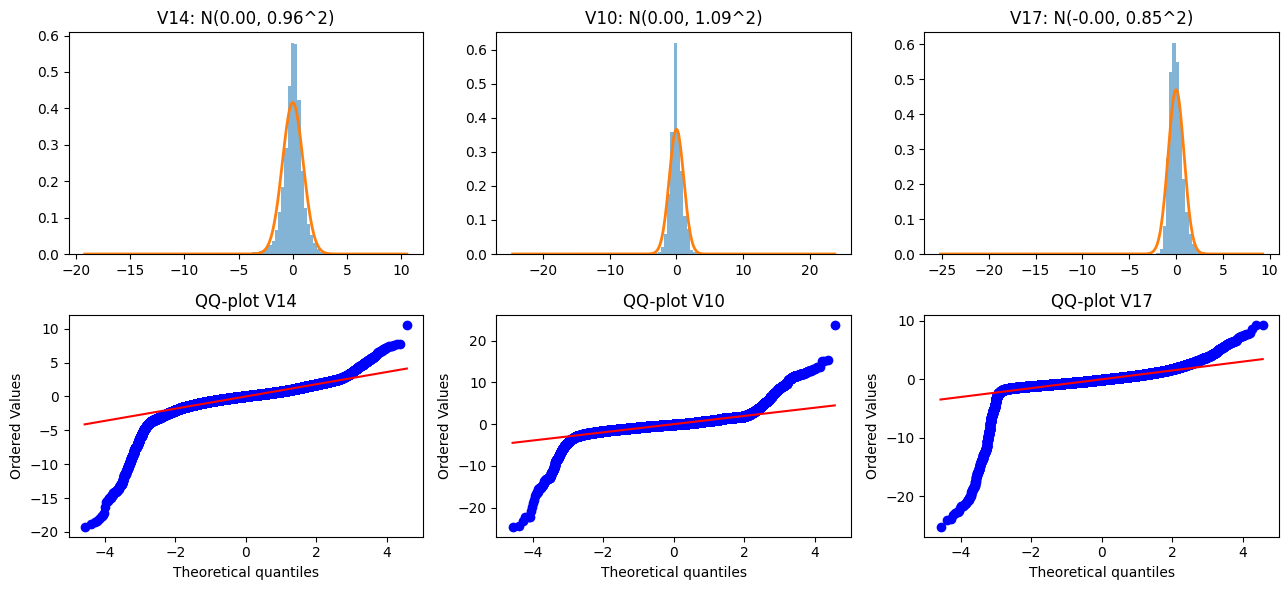

componente   mu  sigma  KS_stat  curtosis_exceso
       V14  0.0 0.9586   0.0793          23.8790
       V10  0.0 1.0888   0.1023          31.9877
       V17 -0.0 0.8493   0.0749          94.7980

Nota: con n=284,807 el test KS rechaza normalidad casi siempre;
el criterio de decision es el QQ-plot (lineal en el centro, colas pesadas) + la curtosis.


In [ ]:
componentes = ["V14", "V10", "V17"]
fig, axes = plt.subplots(2, len(componentes), figsize=(13, 6))
resumen_ajuste = []

for j, col in enumerate(componentes):
    x = df[col].values
    mu, sd, _ = mle_normal(x)
    # Histograma + densidad ajustada
    ax = axes[0, j]
    ax.hist(x, bins=100, density=True, alpha=0.55)
    grid = np.linspace(x.min(), x.max(), 400)
    ax.plot(grid, stats.norm.pdf(grid, mu, sd), lw=2)
    ax.set_title(f"{col}: N({mu:.2f}, {sd:.2f}^2)")
    # QQ-plot
    stats.probplot(x, dist="norm", plot=axes[1, j])
    axes[1, j].set_title(f"QQ-plot {col}")
    ks = stats.kstest((x - mu) / sd, "norm")
    resumen_ajuste.append({"componente": col, "mu": mu, "sigma": sd,
                           "KS_stat": ks.statistic, "curtosis_exceso": stats.kurtosis(x)})

plt.tight_layout(); plt.show()
tabla_ajuste = pd.DataFrame(resumen_ajuste)
R["tabla_ajuste"] = tabla_ajuste
print(tabla_ajuste.round(4).to_string(index=False))
print("\nNota: con n=284,807 el test KS rechaza normalidad casi siempre;")
print("el criterio de decision es el QQ-plot (lineal en el centro, colas pesadas) + la curtosis.")

Asimetria de Amount = 16.94 (una Normal tendria 0)
logL Normal    = -1,964,939.2
logL LogNormal = -1,429,066.6  -> gana LogNormal por 535,873 unidades de log-verosimilitud


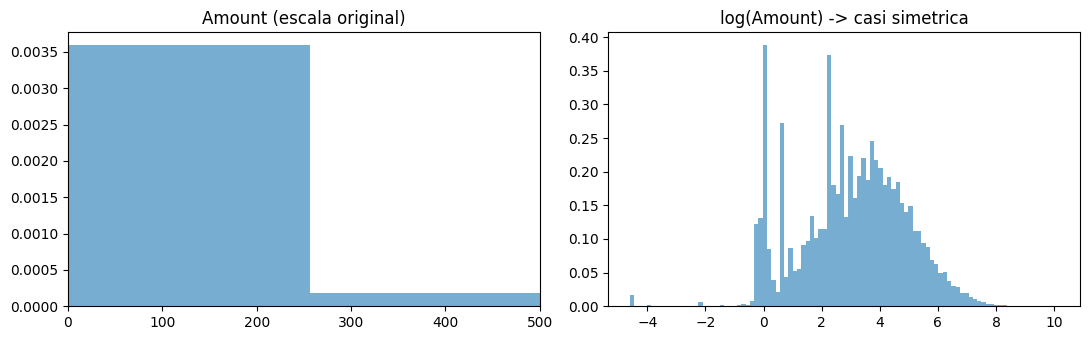

In [ ]:
# Amount NO es gaussiana: es asimetrica positiva -> log-normal es mejor candidata
amt = df.loc[df["Amount"] > 0, "Amount"].values
mu_ln, sd_ln = np.mean(np.log(amt)), np.std(np.log(amt), ddof=0)
ll_lognorm = np.sum(stats.lognorm.logpdf(amt, s=sd_ln, scale=np.exp(mu_ln)))
mu_n, sd_n, ll_n = mle_normal(amt)

R.update({"amount_asimetria": float(stats.skew(amt)), "ll_lognorm": ll_lognorm, "ll_norm_amount": ll_n})
print(f"Asimetria de Amount = {stats.skew(amt):.2f} (una Normal tendria 0)")
print(f"logL Normal    = {ll_n:,.1f}")
print(f"logL LogNormal = {ll_lognorm:,.1f}  -> gana LogNormal por {ll_lognorm-ll_n:,.0f} unidades de log-verosimilitud")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(amt, bins=100, density=True, alpha=0.6); ax[0].set_xlim(0, 500); ax[0].set_title("Amount (escala original)")
ax[1].hist(np.log(amt), bins=100, density=True, alpha=0.6); ax[1].set_title("log(Amount) -> casi simetrica")
plt.tight_layout(); plt.show()

## 5. Esperanza y varianza — monto por clase

In [ ]:
g = df.groupby("Class")["Amount"]
tabla_ev = pd.DataFrame({
    "n": g.size(),
    "E[Amount]": g.mean(),
    "Var[Amount]": g.var(ddof=0),
    "sd": g.std(ddof=0),
    "mediana": g.median(),
    "max": g.max(),
})
tabla_ev["coef_variacion"] = tabla_ev["sd"] / tabla_ev["E[Amount]"]
tabla_ev.index = ["Legitima (0)", "Fraude (1)"]
R["tabla_esperanza_varianza"] = tabla_ev

print(tabla_ev.round(2).to_string())
print()
u = stats.mannwhitneyu(df.loc[df["Class"] == 1, "Amount"], df.loc[df["Class"] == 0, "Amount"])
print(f"Mann-Whitney U p-value = {u.pvalue:.4g}  (test no parametrico: Amount es muy asimetrica)")
print(f"Media fraude / media legitima = {tabla_ev.loc['Fraude (1)','E[Amount]']/tabla_ev.loc['Legitima (0)','E[Amount]']:.2f}x")

                   n  E[Amount]  Var[Amount]      sd  mediana       max  coef_variacion
Legitima (0)  284315      88.29     62552.34  250.10    22.00  25691.16            2.83
Fraude (1)       492     122.21     65752.40  256.42     9.25   2125.87            2.10

Mann-Whitney U p-value = 8.578e-06  (test no parametrico: Amount es muy asimetrica)
Media fraude / media legitima = 1.38x


## 6. Independencia y correlación
Dos verificaciones: (a) las componentes PCA son casi no correlacionadas **por diseño**; (b) test chi-cuadrado de independencia entre `Amount > 200` y `Class`.

In [ ]:
comp = [f"V{i}" for i in range(1, 29)]
corr_pca = df[comp].corr().values
triu = np.triu_indices_from(corr_pca, k=1)
abs_corr = np.abs(corr_pca[triu])

R["corr_pca_media"] = float(abs_corr.mean())
R["corr_pca_max"] = float(abs_corr.max())
print(f"|correlacion| media entre pares de componentes PCA = {abs_corr.mean():.2e}")
print(f"|correlacion| maxima                                = {abs_corr.max():.2e}")
print("-> Ortogonalidad confirmada: no hay multicolinealidad entre V1..V28.\n")

# Correlacion punto-biserial de cada variable con la clase
corr_clase = df[comp + ["Amount", "Time"]].corrwith(df["Class"]).sort_values(key=np.abs, ascending=False)
R["corr_clase_top"] = corr_clase.head(5)
print("Top 5 correlaciones con Class:")
print(corr_clase.head(5).round(4).to_string())
print(f"\nAmount vs Class = {corr_clase['Amount']:.4f}   |   Time vs Class = {corr_clase['Time']:.4f}")

|correlacion| media entre pares de componentes PCA = 6.05e-16
|correlacion| maxima                                = 2.32e-14
-> Ortogonalidad confirmada: no hay multicolinealidad entre V1..V28.

Top 5 correlaciones con Class:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965

Amount vs Class = 0.0056   |   Time vs Class = -0.0123


In [ ]:
# Independencia estadistica: Amount > 200 vs Class (tabla de contingencia)
tabla_cont = pd.crosstab(df["Amount"] > 200, df["Class"])
chi2, pval, dof, esperado = stats.chi2_contingency(tabla_cont)
R.update({"chi2": chi2, "chi2_p": pval})

print("Observado:")
print(tabla_cont.to_string())
print("\nEsperado bajo independencia:")
print(pd.DataFrame(esperado, index=tabla_cont.index, columns=tabla_cont.columns).round(1).to_string())
print(f"\nChi2 = {chi2:.2f}, gl = {dof}, p = {pval:.3e}")
print("Se rechaza independencia, PERO el efecto es minusculo: ver Cramer V.")
V = np.sqrt(chi2 / (n_total * (min(tabla_cont.shape) - 1)))
R["cramer_v"] = V
print(f"Cramer V = {V:.4f}  (0 = independencia total, 1 = dependencia total)")

## 7. Prior y posterior — actualización bayesiana secuencial
Se encadenan dos pruebas independientes (umbral en V14 y umbral en V10) usando **odds** y razones de verosimilitud:
$$\text{odds}_{post} = \text{odds}_{prior}\times LR_1 \times LR_2,\qquad LR=\frac{P(+\mid F)}{P(+\mid\neg F)}$$

In [ ]:
def razon_verosimilitud(col, q=0.01, cola="izq"):
    c = df[col].quantile(q if cola == "izq" else 1 - q)
    pos = df[col] < c if cola == "izq" else df[col] > c
    s = pos[df["Class"] == 1].mean()
    f = pos[df["Class"] == 0].mean()
    return c, s, f, s / f

odds = prior / (1 - prior)
print(f"Prior      P(F) = {prior*100:.4f}%   (odds = {odds:.6f})")

secuencia = [("V14", "izq"), ("V10", "izq")]
historial = []
for col, cola in secuencia:
    c, s, f, lr = razon_verosimilitud(col, 0.01, cola)
    odds = odds * lr
    p = odds / (1 + odds)
    historial.append({"prueba": f"{col} < {c:.2f}", "P(+|F)": s, "P(+|noF)": f, "LR": lr, "P(F) posterior": p})
    print(f"  + {col} < {c:7.3f} | LR = {lr:8.2f}  -> posterior = {p*100:7.3f}%")

hist_bayes = pd.DataFrame(historial)
R["hist_bayes"] = hist_bayes
R["posterior_final"] = historial[-1]["P(F) posterior"]

# El orden de las pruebas NO altera el resultado final: la multiplicacion es conmutativa
odds_inv = prior / (1 - prior)
for col, cola in reversed(secuencia):
    odds_inv *= razon_verosimilitud(col, 0.01, cola)[3]
print(f"\nPosterior con orden invertido = {(odds_inv/(1+odds_inv))*100:.3f}%  -> identico (producto conmutativo)")

Prior      P(F) = 0.1727%   (odds = 0.001730)
  + V14 <  -2.800 | LR =    97.42  -> posterior =  14.426%
  + V10 <  -2.093 | LR =    92.47  -> posterior =  93.972%

Posterior con orden invertido = 93.972%  -> identico (producto conmutativo)


## 8. Entropía — cuánta incertidumbre hay realmente en `Class`

In [ ]:
def entropia(p, base=2):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    p = p / p.sum()
    return float(-np.sum(p * np.log(p) / np.log(base)))

H_class = entropia([1 - prior, prior])
R["H_class"] = H_class

print(f"H(Class) = {H_class:.6f} bits   (maximo posible con 2 clases = 1 bit)")
print(f"Es el {H_class*100:.2f}% de la entropia maxima.")
print(f"Equivale a la incertidumbre de una moneda con p = {prior*100:.4f}%")
print()
# Entropia condicional dado el resultado de la prueba V14
H_cond = 0.0
for val in [True, False]:
    mask = (positivo == val)
    w = mask.mean()
    p1 = df.loc[mask, "Class"].mean()
    H_cond += w * entropia([1 - p1, p1])
R["H_cond_v14"] = H_cond
R["ganancia_info_v14"] = H_class - H_cond
print(f"H(Class | prueba V14) = {H_cond:.6f} bits")
print(f"Ganancia de informacion = {H_class - H_cond:.6f} bits ({(H_class-H_cond)/H_class*100:.1f}% de la incertidumbre)")

H(Class) = 0.018343 bits   (maximo posible con 2 clases = 1 bit)
Es el 1.83% de la entropia maxima.
Equivale a la incertidumbre de una moneda con p = 0.1727%

H(Class | prueba V14) = 0.009711 bits
Ganancia de informacion = 0.008632 bits (47.1% de la incertidumbre)


## 9. Entropía cruzada — función de pérdida del clasificador
Se entrena una regresión logística con y sin `class_weight="balanced"` y se reporta la entropía cruzada (log-loss) en entrenamiento y prueba, contra el **baseline** de predecir siempre el prior (que vale exactamente `H(Class)` en nats/bits).

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

sc = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)

resultados = []
for peso in [None, "balanced"]:
    clf = LogisticRegression(max_iter=2000, class_weight=peso, random_state=RANDOM_STATE)
    clf.fit(X_tr_s, y_tr)
    p_tr, p_te = clf.predict_proba(X_tr_s)[:, 1], clf.predict_proba(X_te_s)[:, 1]
    yhat = (p_te >= 0.5).astype(int)
    resultados.append({
        "class_weight": str(peso),
        "CE_train": log_loss(y_tr, p_tr),
        "CE_test": log_loss(y_te, p_te),
        "precision": precision_score(y_te, yhat, zero_division=0),
        "recall": recall_score(y_te, yhat),
        "AP (PR-AUC)": average_precision_score(y_te, p_te),
    })
    if peso == "balanced":
        modelo_bal, p_te_bal = clf, p_te

tabla_ce = pd.DataFrame(resultados)
R["tabla_entropia_cruzada"] = tabla_ce

# Baseline: predecir siempre el prior -> la entropia cruzada iguala H(Class) (en nats)
ce_base = log_loss(y_te, np.full(len(y_te), prior))
R["ce_baseline"] = ce_base

print(tabla_ce.round(5).to_string(index=False))
print(f"\nBaseline (predecir siempre p={prior:.5f}): CE = {ce_base:.5f} nats = {ce_base/np.log(2):.5f} bits")
print(f"H(Class) calculada en la seccion 8        : {H_class:.5f} bits  -> coinciden")
print("\nOJO: la CE del modelo SIN balanceo es mas baja, pero eso premia predecir 'legitimo' siempre.")
print("Con desbalance extremo la entropia cruzada NO es una metrica de negocio: usar PR-AUC / recall.")

class_weight  CE_train  CE_test  precision  recall  AP (PR-AUC)
        None   0.00361  0.00477    0.85047 0.61486      0.70795
    balanced   0.09322  0.09609    0.06711 0.87838      0.70500

Baseline (predecir siempre p=0.00173): CE = 0.01274 nats = 0.01839 bits
H(Class) calculada en la seccion 8        : 0.01834 bits  -> coinciden

OJO: la CE del modelo SIN balanceo es mas baja, pero eso premia predecir 'legitimo' siempre.
Con desbalance extremo la entropia cruzada NO es una metrica de negocio: usar PR-AUC / recall.


In [ ]:
# Matriz de confusion del modelo balanceado: el costo real de operar el sistema
cm = confusion_matrix(y_te, (p_te_bal >= 0.5).astype(int))
tn, fp, fn, vp = cm.ravel()
R.update({"cm": cm, "alertas_dia": (vp + fp) / (df['Time'].max() / 86400)})
print("Matriz de confusion (umbral 0.5, class_weight=balanced):")
print(pd.DataFrame(cm, index=["real legit", "real fraude"], columns=["pred legit", "pred fraude"]).to_string())
print(f"\nRecall  = {vp/(vp+fn)*100:.1f}%  (fraudes capturados)")
print(f"Precision = {vp/(vp+fp)*100:.2f}%  -> {fp:,} falsas alarmas por {vp} fraudes reales")
print(f"Dias cubiertos por el dataset: {df['Time'].max()/86400:.1f}")

Matriz de confusion (umbral 0.5, class_weight=balanced):
             pred legit  pred fraude
real legit        83488         1807
real fraude          18          130

Recall  = 87.8%  (fraudes capturados)
Precision = 6.71%  -> 1,807 falsas alarmas por 130 fraudes reales
Dias cubiertos por el dataset: 2.0


## 10. Divergencia KL — qué componentes separan mejor fraude de no-fraude
Se discretiza cada componente en 30 bins por cuantiles (con suavizado de Laplace) y se calcula
$$D_{KL}(P_{fraude}\parallel P_{legitima})=\sum_i p_i\log_2\frac{p_i}{q_i}$$

Divergencia KL (fraude || legitima), en bits:
V14    3.4870
V10    3.2086
V12    3.1087
V17    2.9827
V11    2.9370
V4     2.6293
V3     2.5814
V16    2.5435
V7     2.3416
V2     2.0270

...cola inferior (componentes no informativas):
V13    0.1076
V15    0.0876
V22    0.0763

Amount: KL = 0.6282 bits -> puesto 22 de 29


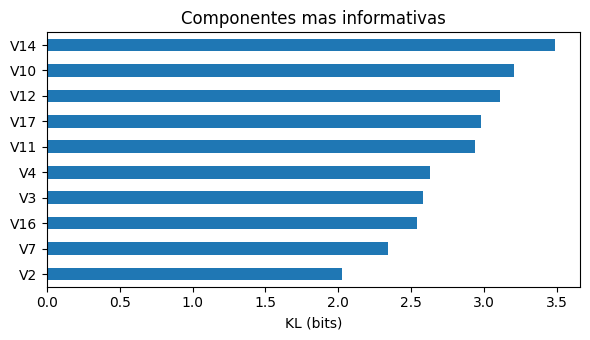

In [ ]:
def kl_divergencia(p, q, base=2):
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    m = p > 0
    return float(np.sum(p[m] * np.log(p[m] / q[m]) / np.log(base)))

def kl_columna(col, n_bins=30):
    bordes = np.unique(np.quantile(df[col], np.linspace(0, 1, n_bins + 1)))
    bordes[0] = df[col].min() - 1e-9
    bordes[-1] = df[col].max() + 1e-9
    cnt_f = np.histogram(df.loc[df["Class"] == 1, col], bins=bordes)[0] + 1   # +1 = Laplace
    cnt_l = np.histogram(df.loc[df["Class"] == 0, col], bins=bordes)[0] + 1
    return kl_divergencia(cnt_f, cnt_l)

kl_scores = pd.Series({c: kl_columna(c) for c in comp + ["Amount"]}).sort_values(ascending=False)
R["kl_scores"] = kl_scores

print("Divergencia KL (fraude || legitima), en bits:")
print(kl_scores.head(10).round(4).to_string())
print("\n...cola inferior (componentes no informativas):")
print(kl_scores.tail(3).round(4).to_string())
print(f"\nAmount: KL = {kl_scores['Amount']:.4f} bits -> puesto {list(kl_scores.index).index('Amount')+1} de {len(kl_scores)}")

kl_scores.head(10).iloc[::-1].plot(kind="barh")
plt.xlabel("KL (bits)"); plt.title("Componentes mas informativas"); plt.tight_layout(); plt.show()

KL(F || L) para V14 = 3.4870 bits
KL(L || F) para V14 = 2.5474 bits  -> asimetrica


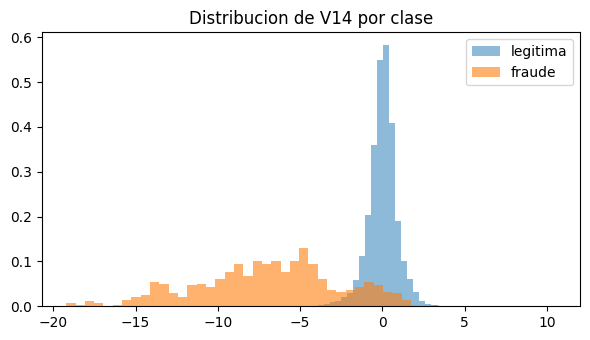

In [ ]:
# La KL NO es simetrica: verificarlo con la componente mas informativa
top = kl_scores.index[0]
bordes = np.unique(np.quantile(df[top], np.linspace(0, 1, 31)))
bordes[0] -= 1e-9; bordes[-1] += 1e-9
cf = np.histogram(df.loc[df["Class"] == 1, top], bins=bordes)[0] + 1
cl = np.histogram(df.loc[df["Class"] == 0, top], bins=bordes)[0] + 1
R["kl_top"] = top
print(f"KL(F || L) para {top} = {kl_divergencia(cf, cl):.4f} bits")
print(f"KL(L || F) para {top} = {kl_divergencia(cl, cf):.4f} bits  -> asimetrica")

plt.hist(df.loc[df["Class"] == 0, top], bins=80, density=True, alpha=0.5, label="legitima")
plt.hist(df.loc[df["Class"] == 1, top], bins=40, density=True, alpha=0.6, label="fraude")
plt.legend(); plt.title(f"Distribucion de {top} por clase"); plt.tight_layout(); plt.show()

## 11. Recomendación accionable — ¿un umbral único de monto?
Se evalúa el trade-off entre cobertura de fraude y volumen de alertas para cada umbral de `Amount`.

In [ ]:
rec = tabla_cond.copy()
rec["alertas_por_fraude"] = rec["n_transacciones"] / rec["n_fraudes"].replace(0, np.nan)
R["tabla_recomendacion"] = rec
print(rec[["umbral", "P(fraude|A>u)_%", "lift_vs_prior", "cobertura_fraude_%",
           "%_transacciones_alertadas", "alertas_por_fraude"]].round(3).to_string(index=False))
print()
print("EVIDENCIA PARA LA RECOMENDACION:")
print(f"- Ningun umbral de monto lleva P(fraude|A>u) por encima del 1%: el mejor queda en "
      f"{rec['P(fraude|A>u)_%'].max():.3f}%")
print(f"- KL(Amount) = {kl_scores['Amount']:.4f} bits vs KL({kl_scores.index[0]}) = {kl_scores.iloc[0]:.4f} bits "
      f"({kl_scores.iloc[0]/kl_scores['Amount']:.0f}x mas informativa).")

if 'cramer_v' not in R:
    tabla_cont_for_cramer = pd.crosstab(df["Amount"] > 200, df["Class"])
    chi2_for_cramer, _, _, _ = stats.chi2_contingency(tabla_cont_for_cramer)
    V_for_cramer = np.sqrt(chi2_for_cramer / (R['n_total'] * (min(tabla_cont_for_cramer.shape) - 1)))
    R['cramer_v'] = V_for_cramer

print(f"- Correlacion Amount-Class = {corr_clase['Amount']:.4f}; Cramer V = {R['cramer_v']:.4f}.")
print("=> Recomendacion: NO usar el monto como disparador unico. Usar un score multivariado")
print("   (V14/V10/V12) y reservar el monto como criterio de PRIORIZACION de la cola de revision.")

 umbral  P(fraude|A>u)_%  lift_vs_prior  cobertura_fraude_%  %_transacciones_alertadas  alertas_por_fraude
      0            0.164          0.951              94.512                     99.359             608.563
     50            0.198          1.148              37.805                     32.921             504.097
    100            0.230          1.332              26.423                     19.841             434.677
    200            0.295          1.706              17.276                     10.125             339.259
    500            0.383          2.216               7.114                      3.210             261.200
   1000            0.306          1.772               1.829                      1.032             326.667
   2000            0.148          0.856               0.203                      0.237             676.000
   5000            0.000          0.000               0.000                      0.019                 NaN

EVIDENCIA PARA LA RECOMENDACION:
- N

## Resumen de cifras para el informe gerencial y la defensa oral

In [ ]:
print("=" * 68)
print("CIFRAS CLAVE — PROPUESTA C (FRAUDE)")
print("=" * 68)
print(f"1.  Prior P(fraude)                     : {R['prior']*100:.4f}%  ({R['n_fraude']} de {R['n_total']:,})")
print(f"2.  P(fraude | Amount > 200)            : {R['P_fraude_dado_A200']:.4f}%")
print(f"3.  Prueba V14 < {R['c_v14']:.2f}: sens {R['sens_v14']*100:.1f}%, espec {R['espec_v14']*100:.2f}%")
print(f"4.  Posterior P(fraude | prueba +)      : {R['posterior_v14']*100:.2f}%  ({R['posterior_v14']/R['prior']:.0f}x el prior)")
print(f"5.  Accuracy del clasificador trivial   : {R['acc_trivial']*100:.3f}%  con 0 fraudes detectados")
print(f"6.  MLE V14 | fraude                    : mu={R['v14_mu_fraude']:.3f}, sigma={R['v14_sd_fraude']:.3f}")
print(f"    MLE V14 | legitima                  : mu={R['v14_mu_legit']:.3f}, sigma={R['v14_sd_legit']:.3f}  (d={R['v14_cohen_d']:.2f})")
print(f"7.  E[Amount] fraude / legitima         : {R['tabla_esperanza_varianza'].loc['Fraude (1)','E[Amount]']:.2f} vs {R['tabla_esperanza_varianza'].loc['Legitima (0)','E[Amount]']:.2f}")
print(f"8.  |corr| media entre componentes PCA  : {R['corr_pca_media']:.2e}  (max {R['corr_pca_max']:.2e})")

# Ensure 'chi2' and 'chi2_p' are available in R, in case previous cell was not run
if 'chi2' not in R:
    tabla_cont = pd.crosstab(df["Amount"] > 200, df["Class"])
    chi2, pval, dof, esperado = stats.chi2_contingency(tabla_cont)
    R.update({"chi2": chi2, "chi2_p": pval})

print(f"9.  Chi2 Amount>200 vs Class            : {R['chi2']:.1f} (p={R['chi2_p']:.2e}), Cramer V={R['cramer_v']:.4f}")
print(f"10. Posterior bayesiano secuencial      : {R['posterior_final']*100:.2f}% tras 2 pruebas")
print(f"11. H(Class)                            : {R['H_class']:.6f} bits ({R['H_class']*100:.2f}% del maximo)")
print(f"    H(Class | prueba V14)               : {R['H_cond_v14']:.6f} bits (ganancia {R['ganancia_info_v14']:.6f})")
print(f"12. Entropia cruzada (balanced) test    : {R['tabla_entropia_cruzada'].loc[1,'CE_test']:.5f} nats  |  baseline {R['ce_baseline']:.5f}")
print(f"13. KL mas alta: {R['kl_top']:<6}                 : {R['kl_scores'].iloc[0]:.4f} bits")
print(f"    KL de Amount                        : {R['kl_scores']['Amount']:.4f} bits")
print("=" * 68)

CIFRAS CLAVE — PROPUESTA C (FRAUDE)
1.  Prior P(fraude)                     : 0.1727%  (492 de 284,807)
2.  P(fraude | Amount > 200)            : 0.2948%
3.  Prueba V14 < -2.80: sens 83.5%, espec 99.14%
4.  Posterior P(fraude | prueba +)      : 14.43%  (84x el prior)
5.  Accuracy del clasificador trivial   : 99.827%  con 0 fraudes detectados
6.  MLE V14 | fraude                    : mu=-6.972, sigma=4.275
    MLE V14 | legitima                  : mu=0.012, sigma=0.897  (d=-2.26)
7.  E[Amount] fraude / legitima         : 122.21 vs 88.29
8.  |corr| media entre componentes PCA  : 6.05e-16  (max 2.32e-14)
9.  Chi2 Amount>200 vs Class            : 26.9 (p=2.12e-07), Cramer V=0.0097
10. Posterior bayesiano secuencial      : 93.97% tras 2 pruebas
11. H(Class)                            : 0.018343 bits (1.83% del maximo)
    H(Class | prueba V14)               : 0.009711 bits (ganancia 0.008632)
12. Entropia cruzada (balanced) test    : 0.09609 nats  |  baseline 0.01274
13. KL mas alta: V14   